In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Importing Libraries

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForMultipleChoice, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score
import wandb
from kaggle_secrets import UserSecretsClient
from dataclasses import dataclass, asdict

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid", palette="muted")

Using device: cuda


# Loading Dataset

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
print("Datasets loaded!")

Datasets loaded!


# Exploratory Data Analysis

## Basic Dataset Statistics

In [4]:
print("-" * 50)
print("BASIC DATASET STATISTICS")
print("-" * 50)
print(f"Total rows: {len(train_df)}")
print(f"Missing values:\n{train_df.isnull().sum()}\n")

--------------------------------------------------
BASIC DATASET STATISTICS
--------------------------------------------------
Total rows: 2000
Missing values:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64



## Checking Class Distribution for Imbalance

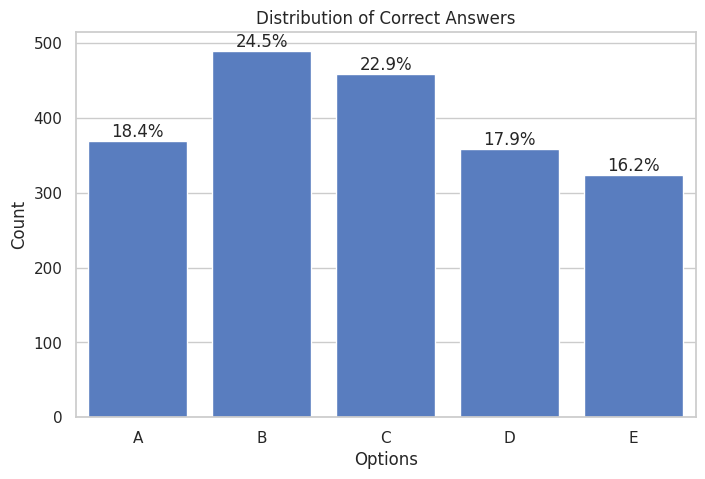

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='answer', order=['A', 'B', 'C', 'D', 'E'])
plt.title("Distribution of Correct Answers")
plt.xlabel("Options")
plt.ylabel("Count")
    
# Add percentage labels
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

## Text Analysis

--------------------------------------------------
TEXT LENGTH ANALYSIS (Word Counts)
--------------------------------------------------


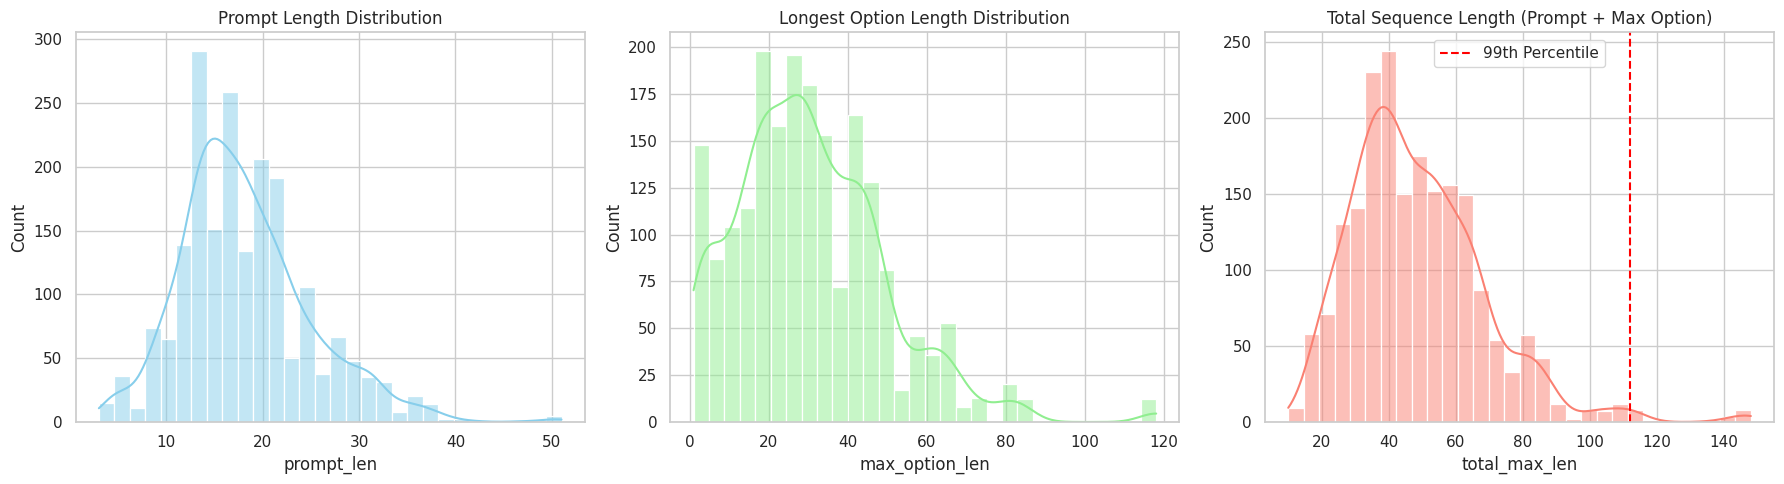

Max Prompt Length: 51 words
Max Option Length: 118 words
Max Total Sequence: 148 words
99th Percentile Total Sequence: 112 words


In [6]:
print("-" * 50)
print("TEXT LENGTH ANALYSIS (Word Counts)")
print("-" * 50)

df = train_df.copy()

# Calculate word counts
df['prompt_len'] = df['prompt'].apply(lambda x: len(str(x).split()))
options = ['A', 'B', 'C', 'D', 'E']
for opt in options:
    df[f'{opt}_len'] = df[opt].apply(lambda x: len(str(x).split()))
        
# Calculate the max option length for each row
df['max_option_len'] = df[[f'{opt}_len' for opt in options]].max(axis=1)
    
# Total length = Prompt + Longest Option (This determines max_length for BERT)
df['total_max_len'] = df['prompt_len'] + df['max_option_len']
    
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
sns.histplot(df['prompt_len'], bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Prompt Length Distribution')
    
sns.histplot(df['max_option_len'], bins=30, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Longest Option Length Distribution')
    
sns.histplot(df['total_max_len'], bins=30, ax=axes[2], color='salmon', kde=True)
axes[2].set_title('Total Sequence Length (Prompt + Max Option)')
axes[2].axvline(df['total_max_len'].quantile(0.99), color='red', linestyle='dashed', label='99th Percentile')
axes[2].legend()
    
plt.tight_layout()
plt.show()
    
print(f"Max Prompt Length: {df['prompt_len'].max()} words")
print(f"Max Option Length: {df['max_option_len'].max()} words")
print(f"Max Total Sequence: {df['total_max_len'].max()} words")
print(f"99th Percentile Total Sequence: {df['total_max_len'].quantile(0.99):.0f} words")

In [7]:
print("-" * 50)
print("STRUCTURAL BIAS: Does length correlate with correctness?")
print("-" * 50)
    
# Find the length of the correct answer for each row
def get_correct_answer_len(row):
    correct_letter = row['answer']
    return row[f'{correct_letter}_len']
        
df['correct_answer_len'] = df.apply(get_correct_answer_len, axis=1)
    
# Calculate average lengths
avg_correct_len = df['correct_answer_len'].mean()
    
# Calculate average length of INCORRECT answers
def get_avg_incorrect_len(row):
    correct = row['answer']
    incorrect_lens = [row[f'{opt}_len'] for opt in options if opt != correct]
    return np.mean(incorrect_lens)
        
df['avg_incorrect_len'] = df.apply(get_avg_incorrect_len, axis=1)
avg_incorrect_len = df['avg_incorrect_len'].mean()
    
print(f"Average length of CORRECT answers: {avg_correct_len:.2f} words")
print(f"Average length of INCORRECT answers: {avg_incorrect_len:.2f} words")
    
if avg_correct_len > avg_incorrect_len * 1.1:
    print("BIAS DETECTED: Correct answers tend to be significantly longer than incorrect ones.")
else:
    print("NO OBVIOUS BIAS: Correct and incorrect answers are roughly the same length.")

--------------------------------------------------
STRUCTURAL BIAS: Does length correlate with correctness?
--------------------------------------------------
Average length of CORRECT answers: 28.66 words
Average length of INCORRECT answers: 25.68 words
BIAS DETECTED: Correct answers tend to be significantly longer than incorrect ones.


# Define the Model

## Configuration

In [ ]:
@dataclass
class Config:
    model_name: str = "google/electra-base-discriminator"
    max_seq_len: int = 150
    
    epochs: int = 5
    batch_size: int = 16
    gradient_accumulation_steps: int = 1
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    wandb_project: str = "23f2004791-t22026"
    wandb_run_name: str = "electra-base-2"
    
    def to_dict(self):
        return asdict(self)

cfg = Config()

In [9]:
try:
    user_secrets = UserSecretsClient()
    wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=wandb_api_key)
    print("Successfully logged into Weights & Biases!")
except Exception as e:
    print(f"W&B Login Failed.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: adrija935 (23f2004791-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Successfully logged into Weights & Biases!


## Tokenizer and Vocabulary Builder

In [11]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## PyTorch Dataset and DataLoaders

In [13]:
class MCQElectraDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, is_test=False):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test
        self.label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])
        options = [str(row[opt]) for opt in ['A', 'B', 'C', 'D', 'E']]
        
        # Duplicate prompt 5 times to pair with each option
        first_sentences = [prompt] * 5
        second_sentences = options

        # Tokenize (Prompt, Option) pairs
        encoding = self.tokenizer(
            first_sentences,
            second_sentences,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )
        
        item = {
            'input_ids': encoding['input_ids'],
            'attention_mask': encoding['attention_mask']
        }
        
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids']
            
        if not self.is_test:
            item['label'] = torch.tensor(self.label_map[row['answer']], dtype=torch.long)
            
        return item

### Data Preprocessing and Splitting

In [14]:
prefixes_to_remove = [
    r"Pick the best possible answer: ",
    r"Determine the correct option: ",
    r"Select the most accurate option: ",
    r"Identify the correct statement: ",
    r"Which of the following is correct\? ",
    r" among the listed options\."
]

def clean_prompt(text):
    for prefix in prefixes_to_remove:
        text = re.sub(prefix, '', text, flags=re.IGNORECASE)
    return text.strip()

train_df['topic_group'] = train_df['prompt'].apply(clean_prompt)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['topic_group']))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)

train_dataset = MCQElectraDataset(train_split, tokenizer, max_len=cfg.max_seq_len)
val_dataset = MCQElectraDataset(val_split, tokenizer, max_len=cfg.max_seq_len)
test_dataset = MCQElectraDataset(test_df, tokenizer, max_len=cfg.max_seq_len, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

## Defining the Model and Metric

In [16]:
# MAP@3 Metric
def compute_map_at_3(predictions, targets):
    scores = []
    for top_preds, target in zip(predictions, targets):
        score = 0.0
        for rank, pred in enumerate(top_preds):
            if pred == target:
                score = 1.0 / (rank + 1)
                break
        scores.append(score)
    return np.mean(scores)

In [17]:
model = AutoModelForMultipleChoice.from_pretrained(cfg.model_name).to(cfg.device)

total_steps = (len(train_loader) // cfg.gradient_accumulation_steps) * cfg.epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForMultipleChoice LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
sequence_summary.summary.weight                   | MISSING    | 
sequence_summary.summary.bias                     | MISSING    | 
classifier.weight                                 | MISSING    | 
classifier.bias                                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

## Training and Validation

In [18]:
wandb.init(
    project=cfg.wandb_project, 
    name=cfg.wandb_run_name, 
    config=cfg.to_dict(), 
    reinit=True
)

best_map3 = 0.0

scaler = torch.amp.GradScaler('cuda')

for epoch in range(cfg.epochs):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
    for step, batch in enumerate(loop):
        input_ids = batch['input_ids'].to(cfg.device)
        attention_mask = batch['attention_mask'].to(cfg.device)
        labels = batch['label'].to(cfg.device)
        
        kwargs = {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }
        if 'token_type_ids' in batch:
            kwargs['token_type_ids'] = batch['token_type_ids'].to(cfg.device)
            
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(**kwargs)
            loss = outputs.loss / cfg.gradient_accumulation_steps
            
        scaler.scale(loss).backward()
        
        if (step + 1) % cfg.gradient_accumulation_steps == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            
            scheduler.step()
            optimizer.zero_grad()
            
        running_loss += outputs.loss.item() * input_ids.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    
    # Validation Loop
    model.eval()
    val_loss = 0.0
    all_top3_preds = []
    all_top1_preds = []
    all_targets = []
    
    with torch.no_grad():
        val_loop = tqdm(val_loader, desc="Validation")
        for batch in val_loop:
            input_ids = batch['input_ids'].to(cfg.device)
            attention_mask = batch['attention_mask'].to(cfg.device)
            labels = batch['label'].to(cfg.device)
            
            kwargs = {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'labels': labels
            }
            if 'token_type_ids' in batch:
                kwargs['token_type_ids'] = batch['token_type_ids'].to(cfg.device)
                
            outputs = model(**kwargs)
            logits = outputs.logits  # Shape: [Batch_Size, 5]
            
            val_loss += outputs.loss.item() * input_ids.size(0)

            top1_preds = torch.argmax(logits, dim=1)
            _, top3_indices = torch.topk(logits, k=3, dim=1)

            all_top1_preds.append(top1_preds.cpu().numpy())
            all_top3_preds.append(top3_indices.cpu().numpy())
            all_targets.append(labels.cpu().numpy())
            
    val_loss = val_loss / len(val_loader.dataset)
    all_top1_preds = np.concatenate(all_top1_preds, axis=0)
    all_top3_preds = np.concatenate(all_top3_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    val_map3 = compute_map_at_3(all_top3_preds, all_targets)
    val_accuracy = accuracy_score(all_targets, all_top1_preds)
    val_f1 = f1_score(all_targets, all_top1_preds, average='macro')

    print(f"Epoch {epoch+1}/{cfg.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val MAP@3: {val_map3:.4f} | Val Acc: {val_accuracy:.4f} | Val F1: {val_f1:.4f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_map3": val_map3,
        "val_accuracy": val_accuracy,
        "val_f1": val_f1
    })

    if val_map3 > best_map3:
        best_map3 = val_map3
        torch.save(model.state_dict(), "best_electra_model.pt")
        wandb.run.summary["best_map3"] = best_map3
        wandb.run.summary["best_accuracy"] = val_accuracy
        wandb.run.summary["best_f1"] = val_f1
        print(f"New best model saved with MAP@3: {best_map3:.4f}")

wandb.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run 6yfbzuz4
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_073031-6yfbzuz4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run electra-base-2
wandb: ⭐️ View project at https://wandb.ai/23f2004791-dl-genai-project/23f2004791-t22026
wandb: 🚀 View run at https://wandb.ai/23f2004791-dl-genai-project/23f2004791-t22026/runs/6yfbzuz4

Validation: 100%|██████████| 25/25 [00:14<00:00,  1.71it/s]


Epoch 1/5 | Train Loss: 1.4691 | Val Loss: 1.0066 | Val MAP@3: 0.8176 | Val Acc: 0.6957 | Val F1: 0.6974
New best model saved with MAP@3: 0.8176


Validation: 100%|██████████| 25/25 [00:15<00:00,  1.60it/s]


Epoch 2/5 | Train Loss: 0.7091 | Val Loss: 0.5065 | Val MAP@3: 0.9032 | Val Acc: 0.8440 | Val F1: 0.8566
New best model saved with MAP@3: 0.9032


Validation: 100%|██████████| 25/25 [00:15<00:00,  1.62it/s]


...

Validation: 100%|██████████| 25/25 [00:15<00:00,  1.63it/s]


Epoch 5/5 | Train Loss: 0.1309 | Val Loss: 0.2284 | Val MAP@3: 0.9787 | Val Acc: 0.9642 | Val F1: 0.9687


wandb: updating run metadata


New best model saved with MAP@3: 0.9787


wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▅▆█
wandb:   train_loss █▄▂▁▁
wandb: val_accuracy ▁▅███
wandb:       val_f1 ▁▅███
wandb:     val_loss █▄▂▁▁
wandb:     val_map3 ▁▅▇██
wandb: 
wandb: Run summary:
wandb: best_accuracy 0.96419
wandb:       best_f1 0.96871
wandb:     best_map3 0.97869
wandb:         epoch 5
wandb:    train_loss 0.1309
wandb:  val_accuracy 0.96419
wandb:        val_f1 0.96871
wandb:      val_loss 0.2284
wandb:      val_map3 0.97869
wandb: 
wandb: 🚀 View run electra-base-2 at: https://wandb.ai/23f2004791-dl-genai-project/23f2004791-t22026/runs/6yfbzuz4
wandb: ⭐️ View project at: https://wandb.ai/23f2004791-dl-genai-project/23f2004791-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260730_073031-6yfbzuz4/logs


## Inference

In [19]:
model.load_state_dict(torch.load("best_electra_model.pt"))
model.eval()

idx_to_label = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
submission_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(cfg.device)
        attention_mask = batch['attention_mask'].to(cfg.device)
        
        kwargs = {
            'input_ids': input_ids,
            'attention_mask': attention_mask
        }
        if 'token_type_ids' in batch:
            kwargs['token_type_ids'] = batch['token_type_ids'].to(cfg.device)
            
        outputs = model(**kwargs)
        logits = outputs.logits
        _, top3_indices = torch.topk(logits, k=3, dim=1)
        
        for top_three in top3_indices.cpu().numpy():
            pred_str = " ".join([idx_to_label[i] for i in top_three])
            submission_preds.append(pred_str)

## Generate Submission

In [20]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'Prediction': submission_preds
})

submission_df.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'!")
print(submission_df.head())

Submission saved to 'submission.csv'!
   id Prediction
0   1      A C D
1   2      B D E
2   3      B E D
3   4      E C D
4   5      B C D
